<a href="https://colab.research.google.com/github/Afridi-7/Deep_Learning/blob/main/neuralNetwork01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "x1": [0,0,1,1],
    "x2": [0,1,0,1],
    "label": [0,1,1,0]
}

df = pd.DataFrame(data)
print(df)

   x1  x2  label
0   0   0      0
1   0   1      1
2   1   0      1
3   1   1      0


In [3]:
X = df[["x1","x2"]].values
y = df[["label"]].values

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [5]:
np.random.seed(42)

input_size = 2
hidden_size = 3
output_size = 1

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

In [13]:
class NeuralNetwork:

    def __init__(self):
        self.W1 = np.random.randn(2,3)
        self.b1 = np.zeros((1,3))
        self.W2 = np.random.randn(3,1)
        self.b2 = np.zeros((1,1))

    def forward(self,X):

        self.z1 = np.dot(X,self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1,self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self,X,y,learning_rate):

      error_output = y - self.a2
      d_output = error_output * sigmoid_derivative(self.a2)

      error_hidden = d_output.dot(self.W2.T)
      d_hidden = error_hidden * sigmoid_derivative(self.a1)

      self.W2 += self.a1.T.dot(d_output) * learning_rate
      self.b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

      self.W1 += X.T.dot(d_hidden) * learning_rate
      self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    def train(self,X,y,epochs,lr):

      losses = []

      for epoch in range(epochs):

          y_pred = self.forward(X)
          l = loss(y,y_pred)

          self.backward(X,y,lr)

          losses.append(l)

          if epoch % 1000 == 0:
              print("Epoch:",epoch,"Loss:",l)

              return losses

In [14]:
nn = NeuralNetwork()

loss_history = nn.train(X,y,epochs=10000,lr=0.1)

Epoch: 0 Loss: 0.28066307027341086


In [15]:
def loss(y, y_pred):
    return np.mean((y - y_pred)**2)

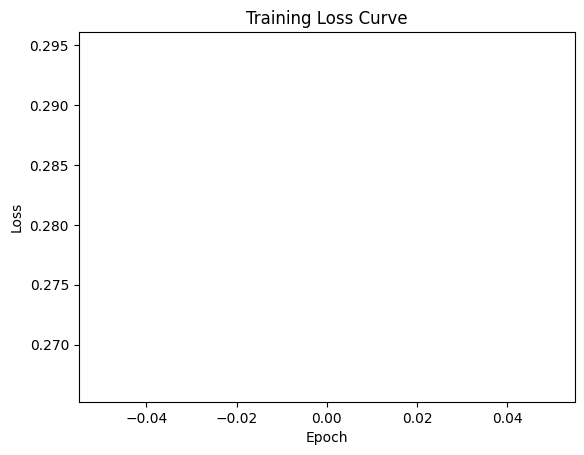

In [16]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [17]:
predictions = nn.forward(X)

print("Predictions:")
print(predictions)

Predictions:
[[0.31685975]
 [0.40474181]
 [0.25993116]
 [0.33729593]]


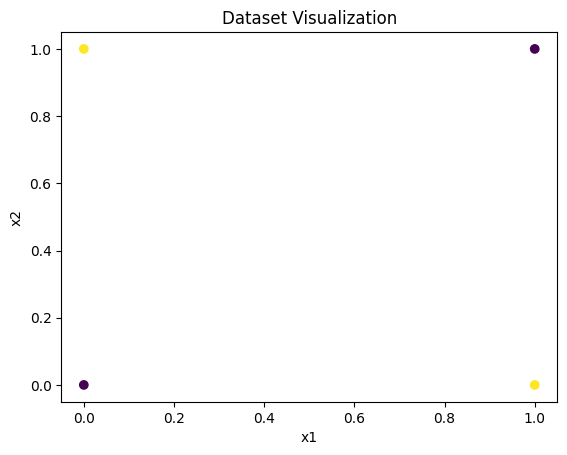

In [18]:
plt.scatter(df["x1"], df["x2"], c=df["label"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Visualization")
plt.show()